# Freddie Mac — 10F without HARP_High_Leverage

Feature importance audit → fixed 10F feature set → fresh baseline CatBoost → fixed parameter CatBoost → Train/CV/Test fit diagnosis. This model retains `DTI_Missing` and removes only `HARP_High_Leverage` from the selected 11F model. It uses the same internal split and threshold as the 11F notebook. Code and comments are in English.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from helpers import *

PROJECT_ROOT = Path(
    r"C:\Users\itwill\Desktop\study\코딩공부\프로젝트"
    r"\The Single Family Loan-Level Dataset (SFLLD) - 6"
)
PROJECT_NAME = "SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams"
MODEL_PATH = PROJECT_ROOT / "notebooks" / PROJECT_NAME / "tuned" / "catboost_tuned.pkl"
DATA_PATH = PROJECT_ROOT / "data" / "output" / "model_ready" / "SFLLD_regular_PIT_train_ML_ready.parquet"
WORK_DIR = PROJECT_ROOT / "notebooks" / PROJECT_NAME / "importance"
RANDOM_STATE = 3217
THRESHOLD = 0.015

for path in [MODEL_PATH, DATA_PATH]:
    if not path.is_file():
        raise FileNotFoundError(f"File not found: {path}")
WORK_DIR.mkdir(parents=True, exist_ok=True)

estimator = my_ml.load_model(MODEL_PATH)
df = pd.read_parquet(DATA_PATH)
print("Loaded model:", MODEL_PATH)
print("Loaded data:", DATA_PATH, df.shape)
print("Output directory:", WORK_DIR)

Loaded model: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\tuned\catboost_tuned.pkl
Loaded data: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\model_ready\SFLLD_regular_PIT_train_ML_ready.parquet (160003, 56)
Output directory: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance


In [2]:
FEATURES_11F = [
    "FICO_Score", "Original_DTI", "Original_CLTV", "Original_Interest_Rate",
    "Number_of_Borrowers", "DTI_Missing", "HARP_High_Leverage",
    "Spatial_Cluster_Region", "Housing_HPI_Growth_12M",
    "BLS_Unemployment_Rate_Change_12M_Final", "Regular_MSA_Macro_Cluster_A",
]
CATEGORICAL_11F = [
    "DTI_Missing", "HARP_High_Leverage", "Spatial_Cluster_Region",
    "Regular_MSA_Macro_Cluster_A",
]
missing = [col for col in FEATURES_11F + ["Target_24M"] if col not in df.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}")

df = my_qtcheck.set_type(df, as_category=CATEGORICAL_11F)
X = df[FEATURES_11F].copy()
y = df["Target_24M"].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Positive events in test:", int(y_test.sum()))

<class 'pandas.DataFrame'>
RangeIndex: 160003 entries, 0 to 160002
Data columns (total 56 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   Loan_ID                                 160003 non-null  str           
 1   FICO_Score                              160003 non-null  float64       
 2   First_Payment_Date                      160003 non-null  datetime64[us]
 3   First_Time_Homebuyer                    160003 non-null  int64         
 4   Maturity_Date                           160003 non-null  datetime64[us]
 5   MSA                                     160003 non-null  int64         
 6   MI_Percentage                           160003 non-null  float64       
 7   Number_of_Units                         160003 non-null  int64         
 8   Occupancy_Status                        160003 non-null  int64         
 9   Original_CLTV                           160003 n

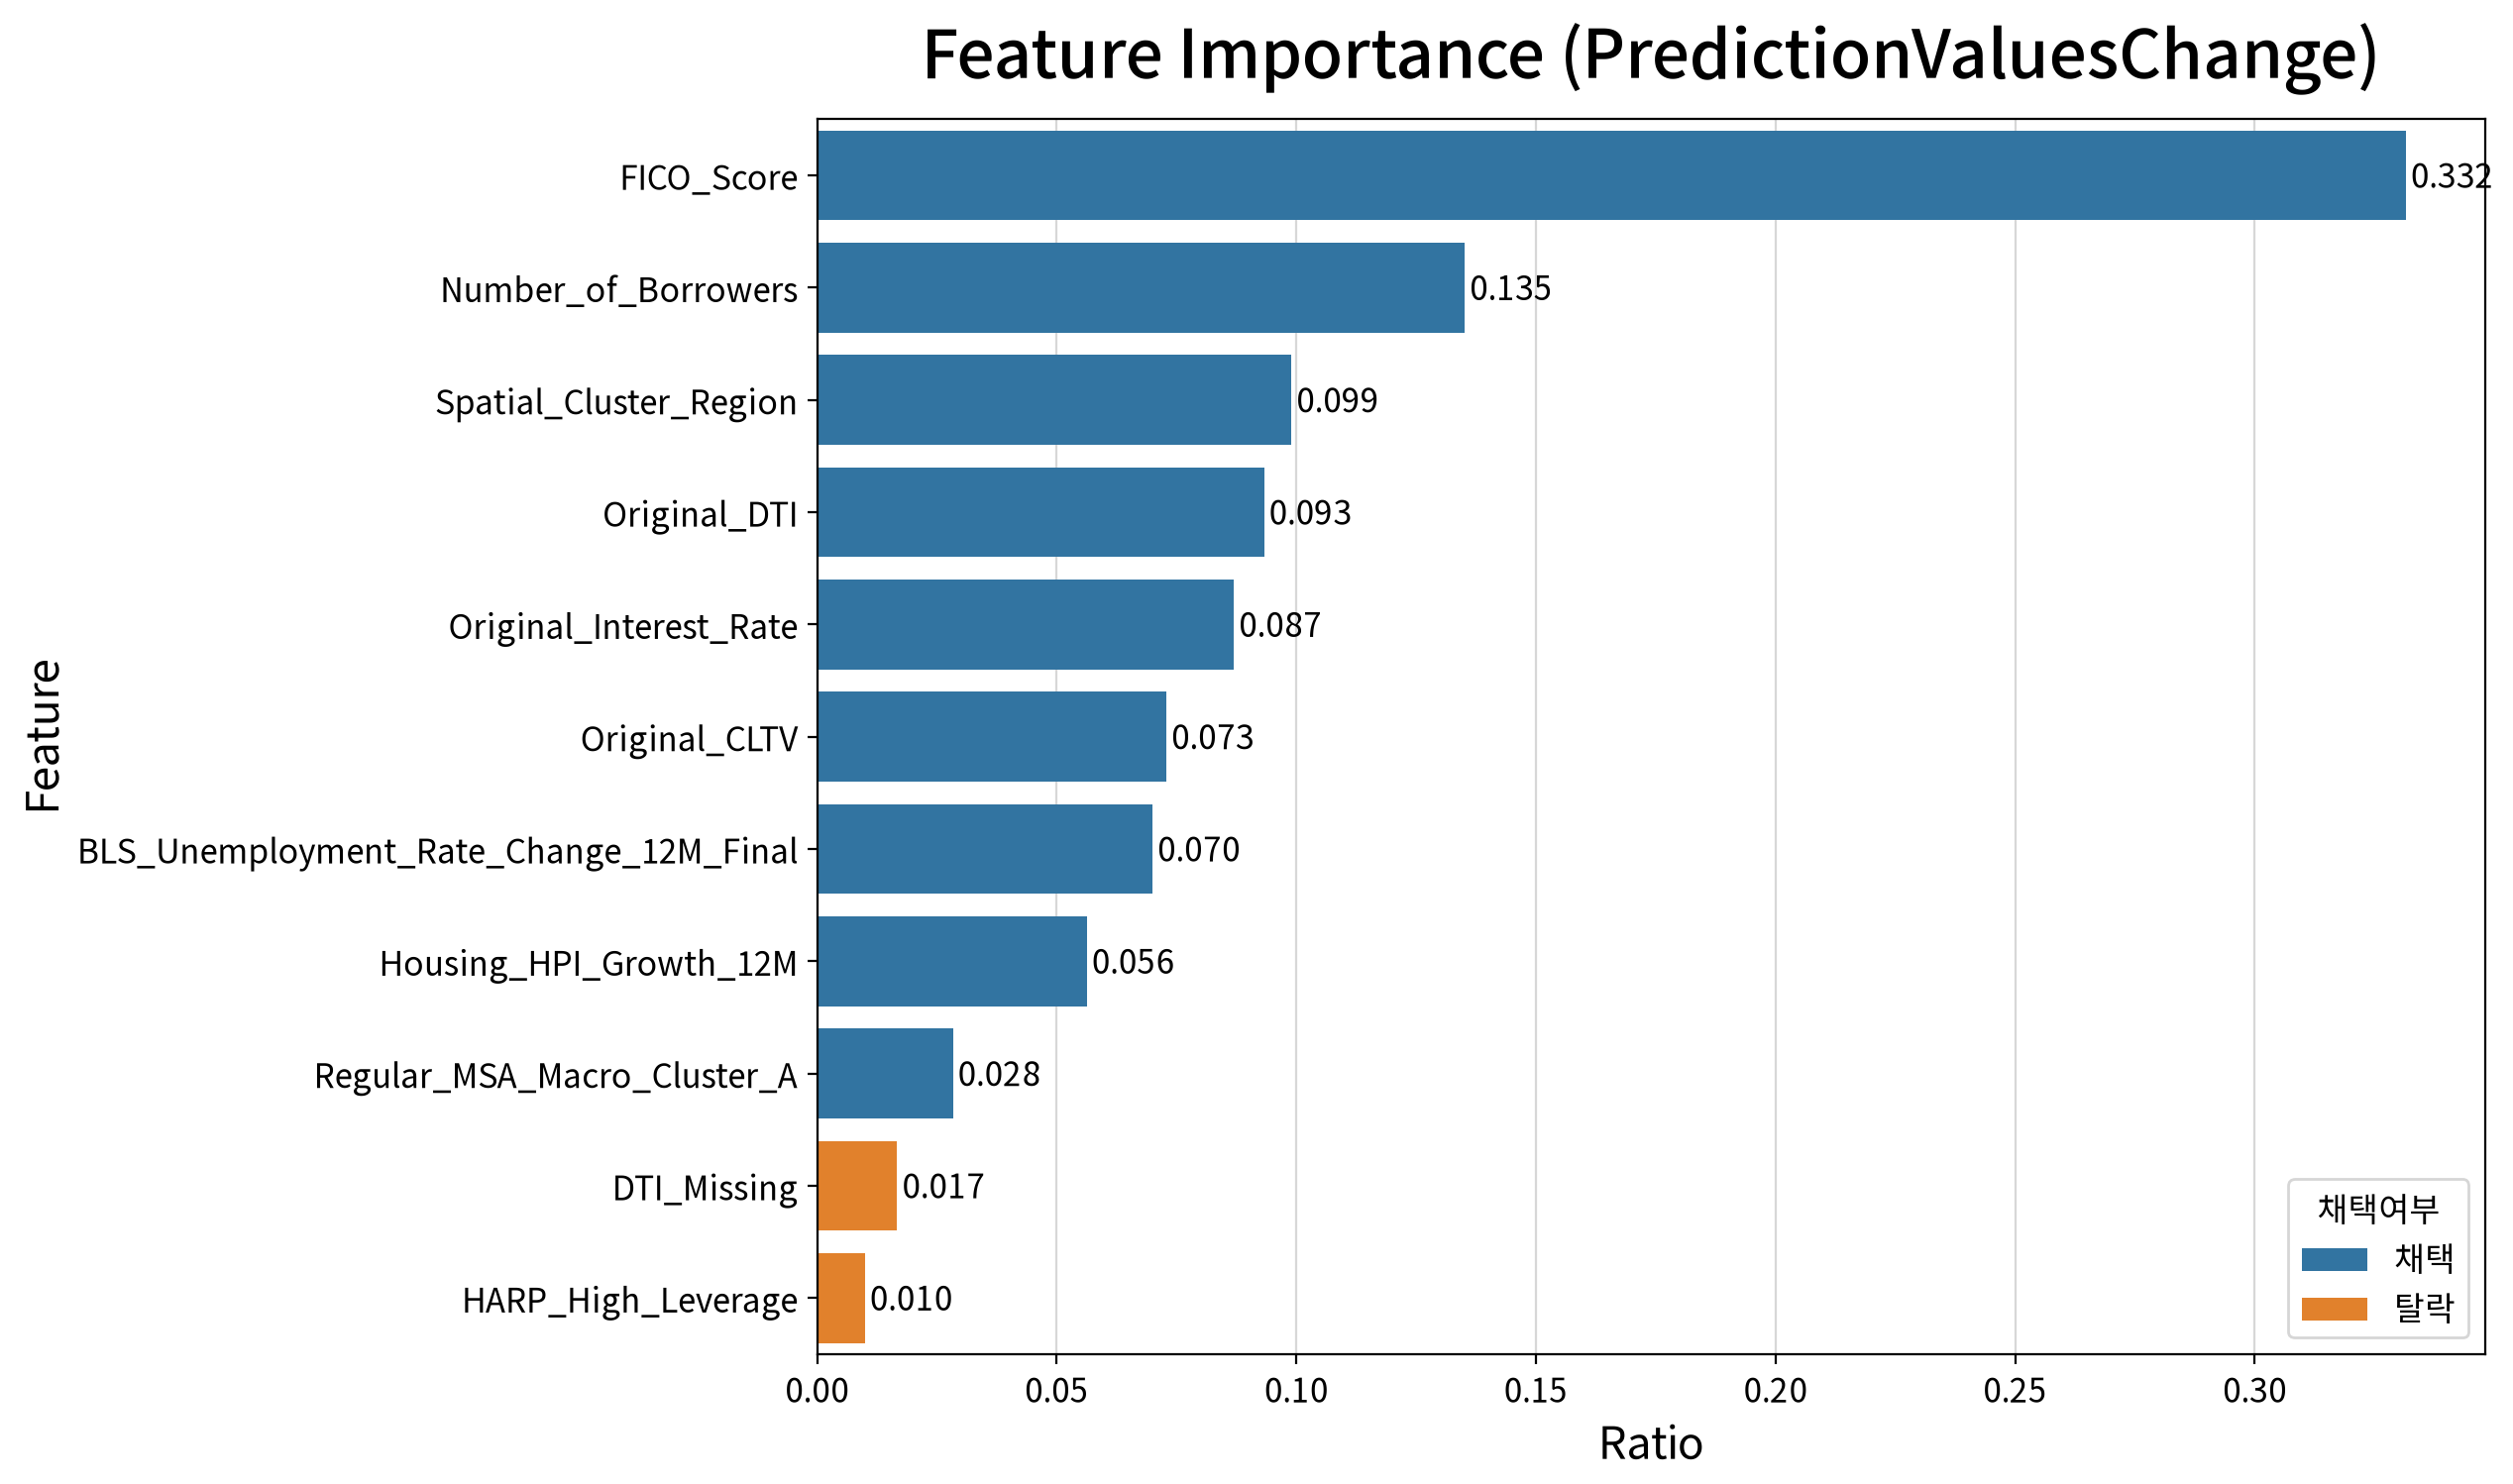

,Importance,Ratio,CumRatio,채택여부
Feature,,,,
FICO_Score,33.151771,0.331518,0.331518,채택
Number_of_Borrowers,13.513858,0.135139,0.466656,채택
Spatial_Cluster_Region,9.897194,0.098972,0.565628,채택
Original_DTI,9.325985,0.093260,0.658888,채택
Original_Interest_Rate,8.697126,0.086971,0.745859,채택
Original_CLTV,7.288592,0.072886,0.818745,채택
BLS_Unemployment_Rate_Change_12M_Final,6.998571,0.069986,0.888731,채택
Housing_HPI_Growth_12M,5.627996,0.056280,0.945011,채택
Regular_MSA_Macro_Cluster_A,2.832045,0.028320,0.973331,채택


In [3]:
# Inspect the original 11F model without using its importance as an automatic deletion rule.
fi = my_diag.feature_importance(estimator, cum_ratio=0.95)
display(fi)

In [4]:
# Explicit controlled ablation: remove HARP_High_Leverage only.
FEATURES_10F = [col for col in FEATURES_11F if col != "HARP_High_Leverage"]
CATEGORICAL_10F = [col for col in CATEGORICAL_11F if col != "HARP_High_Leverage"]
X_train_imp = X_train[FEATURES_10F].copy()
X_test_imp = X_test[FEATURES_10F].copy()

assert len(FEATURES_10F) == 10
assert "DTI_Missing" in FEATURES_10F and "HARP_High_Leverage" not in FEATURES_10F
assert X_train_imp.columns.tolist() == X_test_imp.columns.tolist()
assert not X_train_imp.isna().any().any() and not X_test_imp.isna().any().any()
for col in CATEGORICAL_10F:
    assert isinstance(X_train_imp[col].dtype, pd.CategoricalDtype), (col, X_train_imp[col].dtype)
    assert isinstance(X_test_imp[col].dtype, pd.CategoricalDtype), (col, X_test_imp[col].dtype)

print("10F features:", FEATURES_10F)
print("Categorical dtypes:\n", X_train_imp[CATEGORICAL_10F].dtypes)
print("Continuous features:", [c for c in FEATURES_10F if c not in CATEGORICAL_10F])

10F features: ['FICO_Score', 'Original_DTI', 'Original_CLTV', 'Original_Interest_Rate', 'Number_of_Borrowers', 'DTI_Missing', 'Spatial_Cluster_Region', 'Housing_HPI_Growth_12M', 'BLS_Unemployment_Rate_Change_12M_Final', 'Regular_MSA_Macro_Cluster_A']
Categorical dtypes:
 DTI_Missing                    category
Spatial_Cluster_Region         category
Regular_MSA_Macro_Cluster_A    category
dtype: object
Continuous features: ['FICO_Score', 'Original_DTI', 'Original_CLTV', 'Original_Interest_Rate', 'Number_of_Borrowers', 'Housing_HPI_Growth_12M', 'BLS_Unemployment_Rate_Change_12M_Final']


## Fresh baseline with the 10F specification

No VIF filtering or new hyperparameter search runs here. Distinct filenames prevent changes to previously saved models.

In [5]:
baseline_model = my_ml.fit_pipeline(
    model=CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
    x_train=X_train_imp,
    y_train=y_train,
    vif=False,
    scale=False,
    encode=False,
    name="catboost_no_harp_baseline",
    save_path=WORK_DIR / "catboost_no_harp_baseline.pkl",
    verbose=False,
    model__cat_features=CATEGORICAL_10F,
)
print("Saved baseline:", WORK_DIR / "catboost_no_harp_baseline.pkl")

Saved baseline: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\catboost_no_harp_baseline.pkl


In [6]:
# Clone before setting parameters because CatBoost rejects changes to a fitted model.
fixed_model = clone(baseline_model)
fixed_model.set_params(
    model__depth=4,
    model__iterations=500,
    model__learning_rate=0.03,
)
fixed_model.fit(X_train_imp, y_train, model__cat_features=CATEGORICAL_10F)

FIXED_PATH = WORK_DIR / "catboost_no_harp_10F_fixed.pkl"
my_ml.save_model(fixed_model, FIXED_PATH)
print("Saved fixed model:", FIXED_PATH)
print("Parameters:", {k: fixed_model.get_params()[k] for k in [
    "model__depth", "model__iterations", "model__learning_rate"
]})

Saved fixed model: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\catboost_no_harp_10F_fixed.pkl
Parameters: {'model__depth': 4, 'model__iterations': 500, 'model__learning_rate': 0.03}


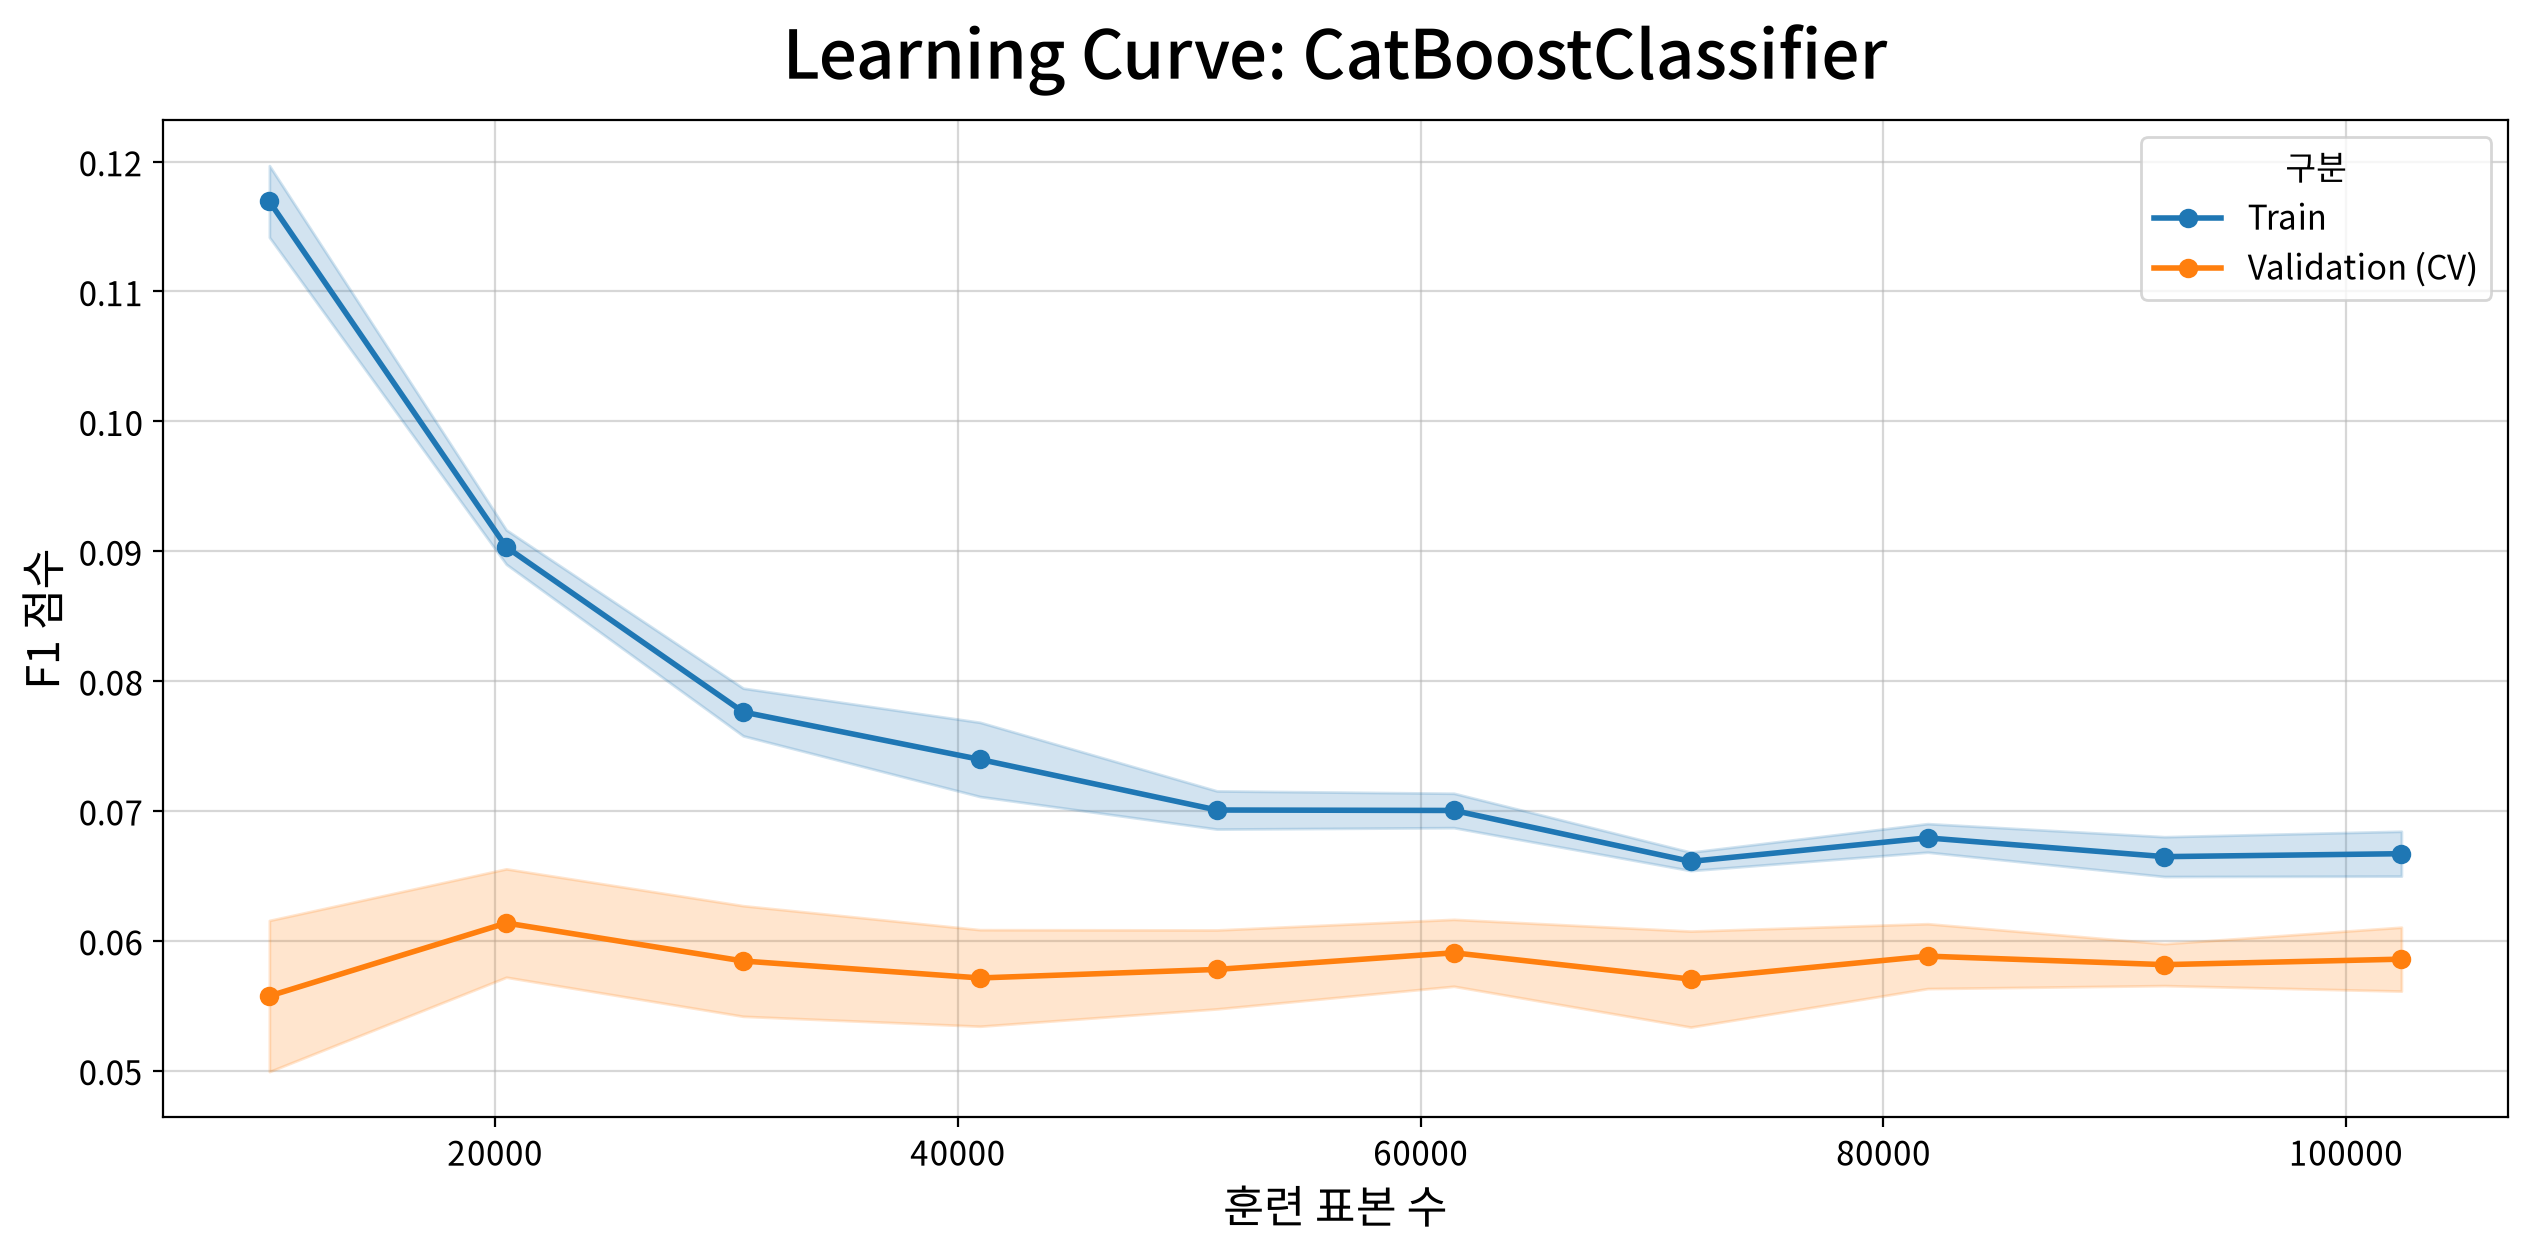

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
F1,0.065002,0.057577,0.002472,0.062522,0.007425,0.74,일반화
PR_AUC,0.100940,0.037391,0.004606,0.047680,0.063549,6.35,일반화
ROC_AUC,0.852061,0.828624,0.008455,0.855422,0.023437,2.34,일반화
Recall,0.517007,0.453061,0.020453,0.472826,0.063946,6.39,일반화
Precision,0.034681,0.030742,0.001319,0.033474,0.003939,0.39,일반화
Accuracy,0.914595,0.914837,0.001050,0.918471,-0.000242,-0.02,일반화



◆ Fit Diagnosis: CatBoostClassifier  (decision_threshold=0.015, gap_threshold=20.0%, 기준=Train↔CV 5-Fold)
   * gap_threshold 는 학술 표준이 아닌 진단용 경험칙입니다. CV 표준편차와 학습곡선 추세를 함께 보세요.
 - F1        Train=     0.0650 CV=     0.0576 (±0.0025) Test=     0.0625 Gap=   0.0074 Gap%=   0.74% [일반화] [정상]
 - PR_AUC    Train=     0.1009 CV=     0.0374 (±0.0046) Test=     0.0477 Gap=   0.0635 Gap%=   6.35% [일반화] [정상]
 - ROC_AUC   Train=     0.8521 CV=     0.8286 (±0.0085) Test=     0.8554 Gap=   0.0234 Gap%=   2.34% [일반화] [정상]
 - Recall    Train=     0.5170 CV=     0.4531 (±0.0205) Test=     0.4728 Gap=   0.0639 Gap%=   6.39% [일반화] [정상]
 - Precision Train=     0.0347 CV=     0.0307 (±0.0013) Test=     0.0335 Gap=   0.0039 Gap%=   0.39% [일반화] [정상]
 - Accuracy  Train=     0.9146 CV=     0.9148 (±0.0011) Test=     0.9185 Gap=  -0.0002 Gap%=  -0.02% [일반화] [정상]

  ▶ 진단: ✔ 일반화 진단 (Good fit) - 설정한 gap 기준 내에서 격차가 작음
     · train ROC_AUC=0.8521 (과소적합 기준 < 0.6) · CV ROC_AUC=0.8286



In [ ]:
overfit_result = my_diag.overfit(
    estimator=fixed_model,
    x_train=X_train_imp,
    y_train=y_train,
    x_test=X_test_imp,
    y_test=y_test,
    metrics=["F1", "PR_AUC", "ROC_AUC", "Recall", "Precision", "Accuracy"],
    decision_threshold=THRESHOLD,
    gap_threshold=0.20,
    fit_params={"model__cat_features": CATEGORICAL_10F},
)